<a href="https://colab.research.google.com/github/aminul-12/Aminul-12/blob/main/CoPython_for_AI_and_Machine_Learning_%E2%80%94_Microsoft_%26_edXpy_of_Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print('All libraries imported successfully.')
print('GlobalPath AI — Student Recommendation System')
print('Microsoft Python for AI and ML — edX')

All libraries imported successfully.
GlobalPath AI — Student Recommendation System
Microsoft Python for AI and ML — edX


In [5]:
# Student profile dataset — simulating GlobalPath student data
# Features: GPA, IELTS Score, Budget (USD/year), Field of Study
# Target: Recommended Country

np.random.seed(42)

data = {
    'Student_ID': range(1, 201),

    'GPA': np.round(np.concatenate([
        np.random.uniform(3.5, 4.0, 50),
        np.random.uniform(3.0, 3.7, 60),
        np.random.uniform(2.5, 3.2, 50),
        np.random.uniform(2.0, 2.8, 40),
    ]), 2),

    'IELTS_Score': np.round(np.concatenate([
        np.random.uniform(7.0, 9.0, 50),
        np.random.uniform(6.5, 8.0, 60),
        np.random.uniform(6.0, 7.5, 50),
        np.random.uniform(5.5, 7.0, 40),
    ]), 1),

    'Budget_USD': np.concatenate([
        np.random.randint(20000, 40000, 50),
        np.random.randint(18000, 35000, 60),
        np.random.randint(22000, 55000, 50),
        np.random.randint(10000, 25000, 40),
    ]),

    'Field': np.random.choice(
        ['Computer Science', 'Engineering',
         'Business', 'Data Science'],
        200
    ),

    'Recommended_Country': np.concatenate([
        np.random.choice(['UK', 'Germany'], 50),
        np.random.choice(['Canada', 'Australia'], 60),
        np.random.choice(['USA', 'Netherlands'], 50),
        np.random.choice(['Sweden', 'France'], 40),
    ])
}

df = pd.DataFrame(data)

print('Dataset created successfully.')
print(f'Total Students : {len(df)}')
print(f'Features       : {list(df.columns)}')
print()
print(df.head(10))

Dataset created successfully.
Total Students : 200
Features       : ['Student_ID', 'GPA', 'IELTS_Score', 'Budget_USD', 'Field', 'Recommended_Country']

   Student_ID   GPA  IELTS_Score  Budget_USD             Field  \
0           1  3.69          8.3       33584      Data Science   
1           2  3.98          7.2       32144      Data Science   
2           3  3.87          7.3       34397      Data Science   
3           4  3.80          8.8       28787  Computer Science   
4           5  3.58          8.2       34191       Engineering   
5           6  3.58          7.0       20728       Engineering   
6           7  3.53          7.2       37749  Computer Science   
7           8  3.93          8.3       20698       Engineering   
8           9  3.80          7.0       27186  Computer Science   
9          10  3.85          7.3       34512       Engineering   

  Recommended_Country  
0             Germany  
1                  UK  
2             Germany  
3             Germany  
4

In [6]:
print('=== DATASET INFORMATION ===')
print(df.info())
print()

print('=== SUMMARY STATISTICS ===')
print(df.describe())
print()

print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()

print('=== COUNTRY DISTRIBUTION ===')
print(df['Recommended_Country'].value_counts())
print()

print('=== FIELD OF STUDY DISTRIBUTION ===')
print(df['Field'].value_counts())

=== DATASET INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           200 non-null    int64  
 1   GPA                  200 non-null    float64
 2   IELTS_Score          200 non-null    float64
 3   Budget_USD           200 non-null    int64  
 4   Field                200 non-null    object 
 5   Recommended_Country  200 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 9.5+ KB
None

=== SUMMARY STATISTICS ===
       Student_ID         GPA  IELTS_Score    Budget_USD
count  200.000000  200.000000   200.000000    200.000000
mean   100.500000    3.126750     7.120500  28041.260000
std     57.879185    0.514711     0.798132   9667.463416
min      1.000000    2.010000     5.500000  10137.000000
25%     50.750000    2.700000     6.600000  21160.500000
50%    100.500000    3.145000  

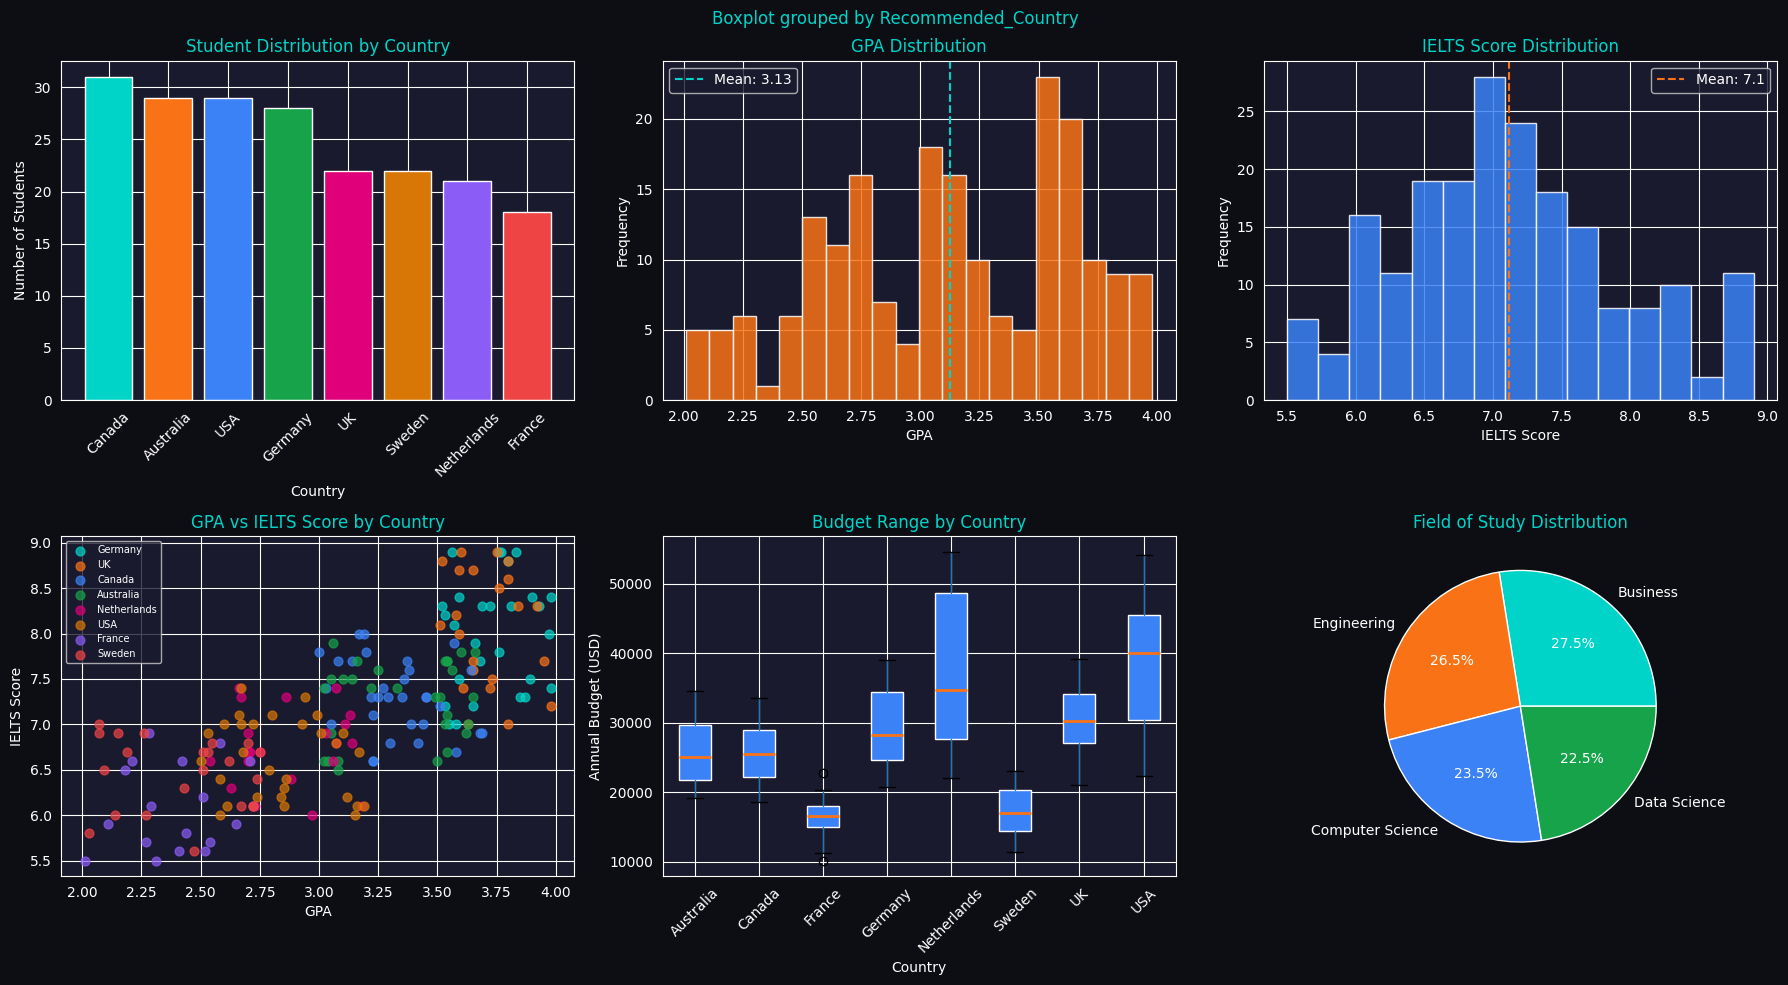

Visualisation complete.


In [7]:
sns.set_style('darkgrid')
plt.rcParams['figure.facecolor'] = '#0d0d14'
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'GlobalPath AI — Student Data Analysis\n'
    'Microsoft Python for AI and ML — edX',
    fontsize=16, color='#00d4c8',
    fontweight='bold', y=1.02
)

# Plot 1 — Country Distribution
country_counts = df['Recommended_Country'].value_counts()
axes[0, 0].bar(
    country_counts.index,
    country_counts.values,
    color=['#00d4c8','#f97316','#3b82f6','#16a34a',
           '#e0007a','#d97706','#8b5cf6','#ef4444']
)
axes[0, 0].set_title('Student Distribution by Country',
                      color='#00d4c8')
axes[0, 0].set_xlabel('Country')
axes[0, 0].set_ylabel('Number of Students')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2 — GPA Distribution
axes[0, 1].hist(df['GPA'], bins=20, color='#f97316',
                edgecolor='white', alpha=0.85)
axes[0, 1].set_title('GPA Distribution', color='#00d4c8')
axes[0, 1].set_xlabel('GPA')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(
    df['GPA'].mean(), color='#00d4c8',
    linestyle='--',
    label=f'Mean: {df["GPA"].mean():.2f}'
)
axes[0, 1].legend()

# Plot 3 — IELTS Score Distribution
axes[0, 2].hist(df['IELTS_Score'], bins=15, color='#3b82f6',
                edgecolor='white', alpha=0.85)
axes[0, 2].set_title('IELTS Score Distribution', color='#00d4c8')
axes[0, 2].set_xlabel('IELTS Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(
    df['IELTS_Score'].mean(), color='#f97316',
    linestyle='--',
    label=f'Mean: {df["IELTS_Score"].mean():.1f}'
)
axes[0, 2].legend()

# Plot 4 — GPA vs IELTS Scatter
countries = df['Recommended_Country'].unique()
colors = ['#00d4c8','#f97316','#3b82f6','#16a34a',
          '#e0007a','#d97706','#8b5cf6','#ef4444']
for i, country in enumerate(countries):
    subset = df[df['Recommended_Country'] == country]
    axes[1, 0].scatter(
        subset['GPA'], subset['IELTS_Score'],
        label=country, alpha=0.7,
        color=colors[i], s=40
    )
axes[1, 0].set_title('GPA vs IELTS Score by Country',
                      color='#00d4c8')
axes[1, 0].set_xlabel('GPA')
axes[1, 0].set_ylabel('IELTS Score')
axes[1, 0].legend(fontsize=7)

# Plot 5 — Budget by Country
df.boxplot(
    column='Budget_USD',
    by='Recommended_Country',
    ax=axes[1, 1],
    patch_artist=True,
    boxprops=dict(facecolor='#3b82f6', color='white'),
    medianprops=dict(color='#f97316', linewidth=2)
)
axes[1, 1].set_title('Budget Range by Country', color='#00d4c8')
axes[1, 1].set_xlabel('Country')
axes[1, 1].set_ylabel('Annual Budget (USD)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot 6 — Field of Study Pie
field_counts = df['Field'].value_counts()
axes[1, 2].pie(
    field_counts.values,
    labels=field_counts.index,
    autopct='%1.1f%%',
    colors=['#00d4c8','#f97316','#3b82f6','#16a34a'],
    textprops={'color': 'white'}
)
axes[1, 2].set_title('Field of Study Distribution',
                      color='#00d4c8')

plt.tight_layout()
plt.savefig('globalpath_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d14')
plt.show()
print('Visualisation complete.')

In [8]:
# Encode categorical features
le_field   = LabelEncoder()
le_country = LabelEncoder()

df['Field_Encoded']   = le_field.fit_transform(df['Field'])
df['Country_Encoded'] = le_country.fit_transform(
                            df['Recommended_Country'])

print('Label Encoding:')
print('Fields    :', dict(zip(
    le_field.classes_,
    le_field.transform(le_field.classes_)
)))
print('Countries :', dict(zip(
    le_country.classes_,
    le_country.transform(le_country.classes_)
)))
print()

# Define features and target
X = df[['GPA','IELTS_Score','Budget_USD','Field_Encoded']]
y = df['Country_Encoded']

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'Features         : GPA, IELTS, Budget, Field')
print(f'Target           : Recommended Country')
print()
print('Preprocessing complete. Ready for model training.')

Label Encoding:
Fields    : {'Business': np.int64(0), 'Computer Science': np.int64(1), 'Data Science': np.int64(2), 'Engineering': np.int64(3)}
Countries : {'Australia': np.int64(0), 'Canada': np.int64(1), 'France': np.int64(2), 'Germany': np.int64(3), 'Netherlands': np.int64(4), 'Sweden': np.int64(5), 'UK': np.int64(6), 'USA': np.int64(7)}

Training samples : 160
Testing samples  : 40
Features         : GPA, IELTS, Budget, Field
Target           : Recommended Country

Preprocessing complete. Ready for model training.


In [9]:
# Model 1 — Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy    = accuracy_score(y_test, rf_predictions)

# Model 2 — K-Nearest Neighbours
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
knn_accuracy    = accuracy_score(y_test, knn_predictions)

# Cross validation
rf_cv  = cross_val_score(rf_model,  X_scaled, y, cv=5).mean()
knn_cv = cross_val_score(knn_model, X_scaled, y, cv=5).mean()

print('=== MODEL TRAINING RESULTS ===')
print()
print('Random Forest Classifier')
print(f'  Test Accuracy      : {rf_accuracy  * 100:.2f}%')
print(f'  Cross-Val Accuracy : {rf_cv        * 100:.2f}%')
print()
print('K-Nearest Neighbours')
print(f'  Test Accuracy      : {knn_accuracy * 100:.2f}%')
print(f'  Cross-Val Accuracy : {knn_cv       * 100:.2f}%')
print()
best = "Random Forest" if rf_accuracy > knn_accuracy else "KNN"
print(f'Best Model : {best}')

=== MODEL TRAINING RESULTS ===

Random Forest Classifier
  Test Accuracy      : 50.00%
  Cross-Val Accuracy : 50.00%

K-Nearest Neighbours
  Test Accuracy      : 40.00%
  Cross-Val Accuracy : 43.00%

Best Model : Random Forest


=== RANDOM FOREST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Australia       0.50      0.67      0.57         6
      Canada       0.60      0.50      0.55         6
      France       0.50      0.25      0.33         4
     Germany       0.60      0.50      0.55         6
 Netherlands       0.29      0.50      0.36         4
      Sweden       0.50      0.75      0.60         4
          UK       0.67      0.50      0.57         4
         USA       0.50      0.33      0.40         6

    accuracy                           0.50        40
   macro avg       0.52      0.50      0.49        40
weighted avg       0.53      0.50      0.50        40



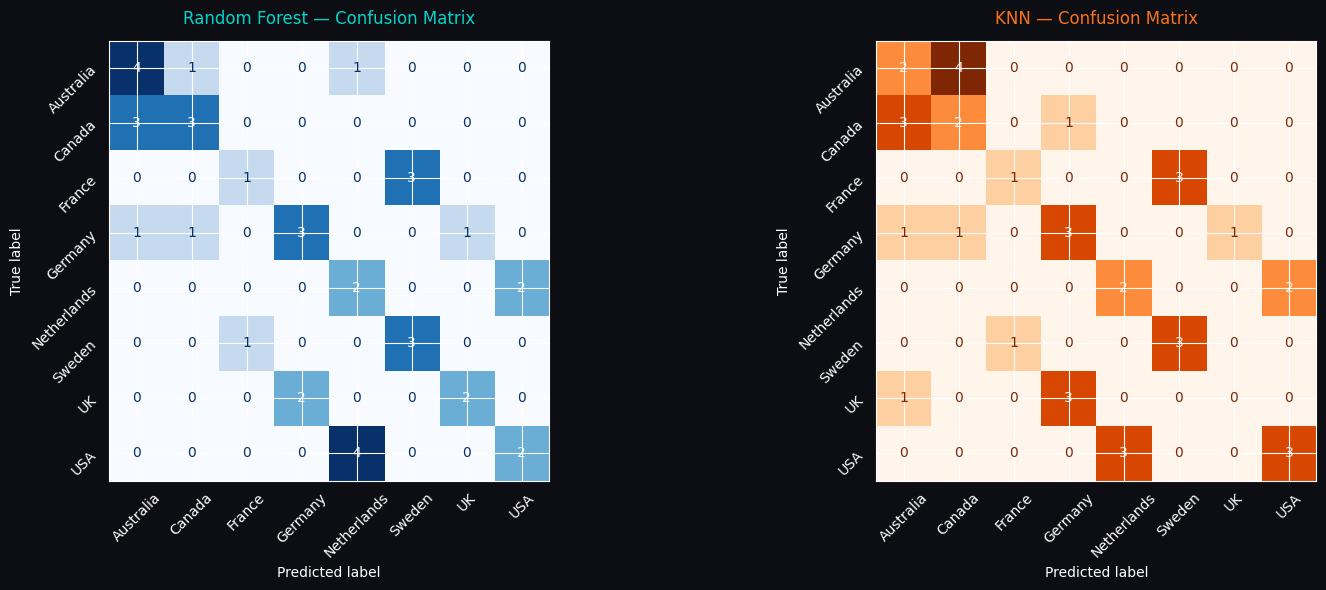

In [10]:
print('=== RANDOM FOREST CLASSIFICATION REPORT ===')
print(classification_report(
    y_test, rf_predictions,
    target_names=le_country.classes_
))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d14')

# Random Forest confusion matrix
cm_rf    = confusion_matrix(y_test, rf_predictions)
disp_rf  = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=le_country.classes_
)
disp_rf.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest — Confusion Matrix',
                   color='#00d4c8', pad=12)
axes[0].set_facecolor('#1a1a2e')
axes[0].tick_params(colors='white', rotation=45)
axes[0].xaxis.label.set_color('white')
axes[0].yaxis.label.set_color('white')

# KNN confusion matrix
cm_knn   = confusion_matrix(y_test, knn_predictions)
disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=le_country.classes_
)
disp_knn.plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('KNN — Confusion Matrix',
                   color='#f97316', pad=12)
axes[1].set_facecolor('#1a1a2e')
axes[1].tick_params(colors='white', rotation=45)
axes[1].xaxis.label.set_color('white')
axes[1].yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d14')
plt.show()

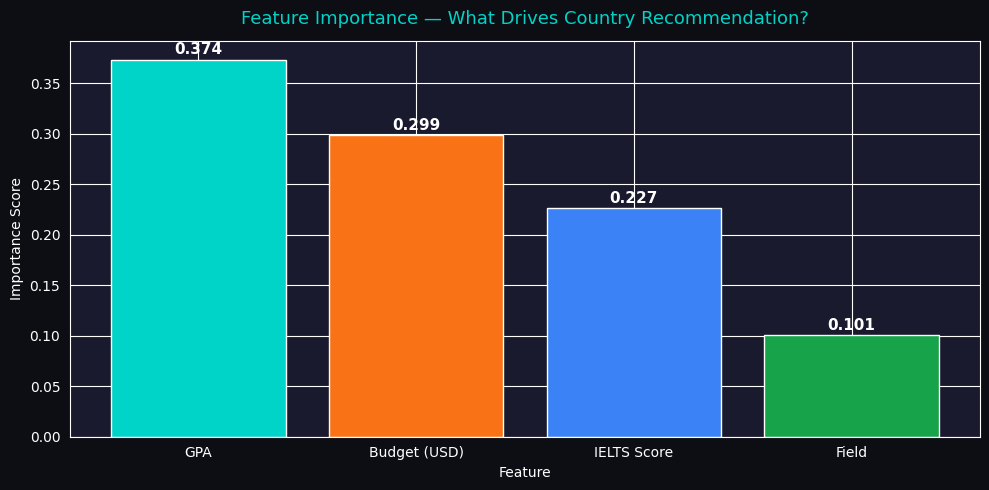

Feature Importance Rankings:
  GPA                  : 0.3736
  Budget (USD)         : 0.2991
  IELTS Score          : 0.2266
  Field                : 0.1008


In [11]:
feature_names = ['GPA','IELTS Score','Budget (USD)','Field']
importances   = rf_model.feature_importances_
indices       = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d0d14')
ax.set_facecolor('#1a1a2e')

bars = ax.bar(
    [feature_names[i] for i in indices],
    importances[indices],
    color=['#00d4c8','#f97316','#3b82f6','#16a34a']
)
ax.set_title(
    'Feature Importance — What Drives Country Recommendation?',
    color='#00d4c8', fontsize=13, pad=12
)
ax.set_xlabel('Feature', color='white')
ax.set_ylabel('Importance Score', color='white')
ax.tick_params(colors='white')

for bar, imp in zip(bars, importances[indices]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{imp:.3f}',
        ha='center', color='white',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d14')
plt.show()

print('Feature Importance Rankings:')
for i in indices:
    print(f'  {feature_names[i]:<20} : {importances[i]:.4f}')

In [12]:
def predict_country(gpa, ielts, budget_usd, field):
    field_encoded = le_field.transform([field])[0]
    input_data    = np.array([[gpa, ielts,
                               budget_usd, field_encoded]])
    input_scaled  = scaler.transform(input_data)
    prediction    = rf_model.predict(input_scaled)
    probabilities = rf_model.predict_proba(input_scaled)[0]
    recommended   = le_country.inverse_transform(prediction)[0]

    print('=== GLOBALPATH STUDENT RECOMMENDATION ===')
    print(f'  GPA          : {gpa}')
    print(f'  IELTS Score  : {ielts}')
    print(f'  Budget       : ${budget_usd:,} USD/year')
    print(f'  Field        : {field}')
    print()
    print(f'  Recommended Country : {recommended}')
    print()
    print('  All Country Probabilities:')

    sorted_probs = sorted(
        zip(le_country.classes_, probabilities),
        key=lambda x: x[1], reverse=True
    )
    for country, prob in sorted_probs:
        bar = '#' * int(prob * 30)
        print(f'  {country:<15} {bar:<30} {prob*100:.1f}%')

    return recommended

# Test with a Bangladeshi CSE student profile
predict_country(
    gpa        = 3.75,
    ielts      = 7.0,
    budget_usd = 25000,
    field      = 'Computer Science'
)

=== GLOBALPATH STUDENT RECOMMENDATION ===
  GPA          : 3.75
  IELTS Score  : 7.0
  Budget       : $25,000 USD/year
  Field        : Computer Science

  Recommended Country : UK

  All Country Probabilities:
  UK              ############                   41.2%
  Germany         ##########                     34.3%
  Canada          ####                           13.5%
  Australia       ###                            10.9%
  France                                         0.0%
  Netherlands                                    0.0%
  Sweden                                         0.0%
  USA                                            0.0%


'UK'

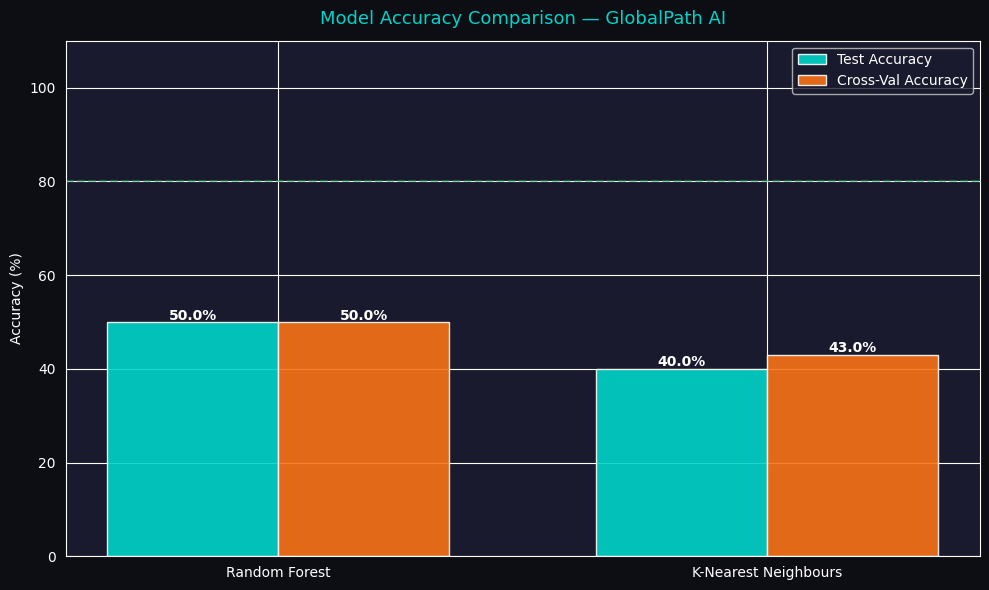

=== FINAL SUMMARY ===
Random Forest Accuracy : 50.00%
KNN Accuracy           : 40.00%
Best Model             : Random Forest

Project : GlobalPath AI — Recommendation System
Course  : Microsoft Python for AI and ML — edX
Live    : https://fyproteam.netlify.app


In [15]:
models     = ['Random Forest', 'K-Nearest Neighbours']
test_scores = [rf_accuracy  * 100, knn_accuracy * 100]
cv_scores   = [rf_cv        * 100, knn_cv       * 100]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d0d14')
ax.set_facecolor('#1a1a2e')

bars1 = ax.bar(x - width/2, test_scores, width,
               label='Test Accuracy',    color='#00d4c8', alpha=0.9)
bars2 = ax.bar(x + width/2, cv_scores,   width,
               label='Cross-Val Accuracy', color='#f97316', alpha=0.9)

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', color='white', fontweight='bold'
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', color='white', fontweight='bold'
    )

ax.set_title('Model Accuracy Comparison — GlobalPath AI',
             color='#00d4c8', fontsize=13, pad=12)
ax.set_ylabel('Accuracy (%)', color='white')
ax.set_xticks(x)
ax.set_xticklabels(models, color='white')
ax.tick_params(colors='white')
ax.set_ylim(0, 110)
ax.legend(facecolor='#1a1a2e', labelcolor='white')
ax.axhline(y=80, color='#16a34a',
           linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d14')
plt.show()

print('=== FINAL SUMMARY ===')
print(f'Random Forest Accuracy : {rf_accuracy  * 100:.2f}%')
print(f'KNN Accuracy           : {knn_accuracy * 100:.2f}%')
best = "Random Forest" if rf_accuracy > knn_accuracy else "KNN"
print(f'Best Model             : {best}')
print()
print('Project : GlobalPath AI — Recommendation System')
print('Course  : Microsoft Python for AI and ML — edX')
print('Live    : https://fyproteam.netlify.app')